### **Aplicação Unificada**

In [3]:
# Importando Bibliotecas
import sys
sys.path.append('../../')

import os
import pandas as pd
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Importando Modelos
from src.models.unet.unet import UNet
from src.models.unet.unet_pretrained import UNet_ImageNet

# Importar sua classe existente
from src.vfss_dataset import VFSSImageDataset

from src.utils import (modify_input,
                       custom_collate_fn,
                       set_seed,
                       avalia_status_GPU)

# Importando classes/funções - Podar imports que não são chamados aqui.
from src.training.config import TrainingConfig
from src.training.loss import (LossCalculator,
                               FocalMSELoss,
                               FocalMSEMaskedLoss)
from src.training.holdout import holdout
from src.training.cross_validation import cross_validate
from src.evalutation.inference import display_inference

set_seed(42)

### **Configuração**

In [4]:
# Atributos da função VFSSImageDataset
output_dim = (448, 448)

transform_augmentation_online = A.Compose([
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 10.0), mean=0, p=0.5),   # Ruído Gaussiano
        A.Resize(output_dim[0], output_dim[1]),
        ToTensorV2()
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_augmentation_offline = A.Compose([
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),

        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano
        A.Resize(output_dim[0], output_dim[1])
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_puro = A.Compose([A.Resize(output_dim[0], output_dim[1]),
                       ToTensorV2()],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Configuração
config = TrainingConfig(
         path_dataframe  = "data/metadados/video_frame_metadata.csv",
         model_class    = UNet_ImageNet,
         model_kwargs   = {"in_channels": 3,
                           "num_keypoints": 2,
                           "return_mode" : "both" # ["both", "heatmap_only", "roi_only"]
                           },
         test_size      = 0.2,
         n_folds        = 5,
         dataset_class  = VFSSImageDataset,
         sigma_heatmap  = 20,

         # Hiperparâmetros do Modelo
         epochs             = 1,
         learning_rate      = 3e-5,
         batch_size         = 8,
         patience           = 10,
         lr_patience        = 1e-10,
         optimizer          = torch.optim.Adam,
         optimizer_kwargs   = {},
         scheduler          = torch.optim.lr_scheduler.ReduceLROnPlateau,

         # Offline Augmentation
         offline_augmentation    = True,
         transform_augmentation  = transform_augmentation_offline,
         augmentation_dir        = "data/frames_augmentation",
         n_aug                   = 5,

         # Funções e Transformações
         output_dim           = output_dim,
         modify_input_fn      = modify_input,
         collate_fn           = custom_collate_fn,
         transform_train      = transform_puro,
         transform_validation = transform_puro,

         # Função de Loss
         criterion_roi       = nn.BCEWithLogitsLoss(),
         criterion_heatmap   = FocalMSELoss(),
         weight_roi          = 0.3,
         weight_heatmap      = 0.5,
         weight_penalty      = 0.2,

         # Outros
         device         = "cuda" if torch.cuda.is_available() else "cpu",
         predict_roi    = True
         )

print("="*50+f"\n{config.model_name}\n"+"="*50)

# Avaliando Status do Uso da GPU
avalia_status_GPU()

Folds all: 92
Test: 23
Overall Dataset - Videos: 234 | Patients: 115 | Frames: 973 (100.0%)
Training + Validation Set - Videos: 192 | Patients: 92 | Frames: 795 (81.7%)
Test Set - Videos: 42 | Patients: 23 | Frames: 178 (18.3%)

Fold 1 - Videos: 41 | Patients: 19 | Frames: 174 (17.9%)
Fold 2 - Videos: 56 | Patients: 19 | Frames: 230 (23.6%)
Fold 3 - Videos: 40 | Patients: 18 | Frames: 168 (17.3%)
Fold 4 - Videos: 26 | Patients: 18 | Frames: 108 (11.1%)
Fold 5 - Videos: 29 | Patients: 18 | Frames: 115 (11.8%)


,split_name,n_videos,n_patients,n_frames,percentage_of_initial_frames,video_ids
0,fold_1,41,19,174,0.178828,"[101, 102, 103, 104, 105, 106, 107, 108, 109, ..."
1,fold_2,56,19,230,0.236382,"[129, 130, 131, 132, 136, 137, 138, 139, 140, ..."
2,fold_3,40,18,168,0.172662,"[122, 123, 125, 126, 127, 128, 152, 153, 154, ..."
3,fold_4,26,18,108,0.110997,"[10, 113, 114, 115, 116, 117, 118, 119, 120, 1..."
4,fold_5,29,18,115,0.118191,"[192, 193, 194, 195, 196, 197, 198, 199, 200, ..."
5,test_set,42,23,178,0.182939,"[100, 11, 13, 142, 143, 144, 145, 146, 147, 14..."


UNet_ImageNet\FocalMSELoss_1ep\1782478702

VERIFICAÇÃO DE GPU
PyTorch version: 2.2.2+cu121
CUDA disponível: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 2080 Ti
Número de GPUs: 1



<class 'torch.Tensor'> <class 'list'> <class 'torch.Tensor'> <class 'torch.Tensor'>


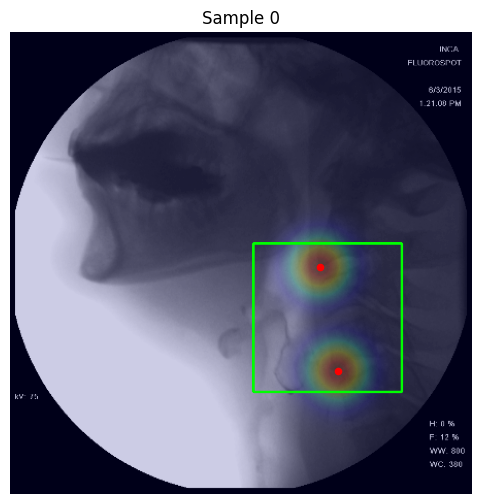

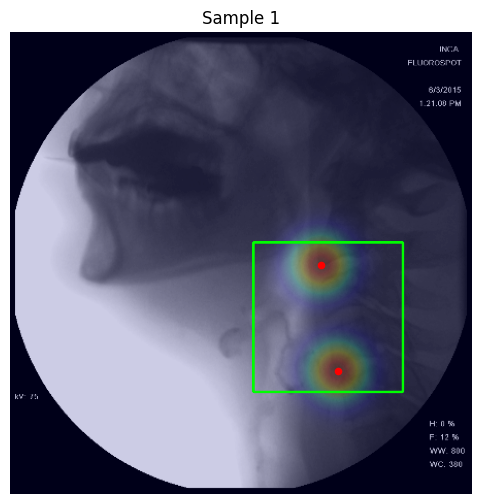

In [3]:
# Conjunto de Teste - PODE APAGAR (só um teste)
test_dataset = VFSSImageDataset(
    video_frame_df = config.df_test,
    output_dim = output_dim,
    transform = transform_puro,      # Sempre sem augmentation para o Teste, então deve ser deterministico -> Resize + ToTensor
    sigma_heatmap = config.sigma_heatmap,
)

print(type(test_dataset[0][0]), type(test_dataset[0][1]), type(test_dataset[0][2]), type(test_dataset[0][3]))
for i in range(2):
    test_dataset.plot_sample(i, True, True, True)

### **Treino/Validação**

In [ ]:
# PODE APAGAR (só um teste)
import time
import torch

# Conjunto de Teste
aux_set = VFSSImageDataset(
    video_frame_df = config.df_test,
    output_dim = config.output_dim,
    transform = config.transform_validation,      # Sempre sem augmentation para o Teste, então deve ser deterministico
    sigma_heatmap = config.sigma_heatmap,
)

num_cores = min(8, os.cpu_count()//4 or 1)
print(num_cores)
train_loader = DataLoader(
            aux_set, batch_size=config.batch_size, shuffle=True,
            collate_fn=config.collate_fn, num_workers=num_cores, pin_memory=True, persistent_workers=True
        )


model = config.model_class(**config.model_kwargs)

model.to(config.device)

# Configuração
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = config.scheduler(
    optimizer,
    mode="min",
    factor=0.1,
    patience=config.patience // 3,  # Quando ver que o negócio tá ficando esquisito, mexe.
)


model.train()
# Pega apenas 1 batch do DataLoader
inputs, keypoints, heatmaps, roi = next(iter(train_loader))

# Manda pra GPU
inputs = inputs.to(config.device)
heatmaps = heatmaps.to(config.device)
roi = roi.to(config.device)

print("Iniciando Raio-X da GPU...\n")

# 1. Testando o Kornia (CLAHE)
torch.cuda.synchronize()
t0 = time.time()
inputs_mod = modify_input(inputs)
torch.cuda.synchronize()
t_kornia = time.time() - t0
print(f"Tempo do modify_input_fn (Kornia): {t_kornia:.4f} segundos")

# 2. Testando o Modelo (Forward Pass)
torch.cuda.synchronize()
t0 = time.time()
pred_roi, pred_heatmap = model(inputs_mod)
torch.cuda.synchronize()
t_model = time.time() - t0
print(f"Tempo do Modelo (Forward Pass): {t_model:.4f} segundos")

# 3. Testando o Loss + Backward Pass
loss_calculator = LossCalculator(config.criterion_roi, config.criterion_heatmap, config)
loss_total, _ = loss_calculator.calculate_loss(pred_roi, pred_heatmap, roi, heatmaps)

torch.cuda.synchronize()
t0 = time.time()
loss_total.backward()
torch.cuda.synchronize()
t_backward = time.time() - t0
print(f"Tempo do Backward Pass: {t_backward:.4f} segundos")

print(f"\nTempo TOTAL para 1 batch na GPU: {t_kornia + t_model + t_backward:.4f} segundos")

6
Iniciando Raio-X da GPU...

Tempo do modify_input_fn (Kornia): 0.2937 segundos
Tempo do Modelo (Forward Pass): 0.5233 segundos
Tempo do Backward Pass: 0.2217 segundos

Tempo TOTAL para 1 batch na GPU: 1.0388 segundos


In [5]:
# TREINO

# Holdout Training sem tunagem
results = holdout(
    df_train=pd.concat([config.list_df_folds[j] for j in range(1,config.n_folds)], ignore_index=True),
    df_val=config.list_df_folds[0],
    config=config,
)

# Cross-validation sem tunagem
# results = cross_validate(
#      config=config
# )

Arquivos antigos de augmentation apagados!


Treinando: 100%|██████████| 389/389 [01:35<00:00,  4.06it/s]


Época 1/1
  Train Loss: 0.0693 | Val Loss: 0.0295
  Val Components - ROI: 0.0762, Heatmap: 0.0122, Penalty: 0.0028
✓ Melhor modelo salvo (val_loss: 0.0295)
✓ Checkpoint carregado: epoch 0, val_loss: 0.0295

Loss Final: 0.0295

RESULTADOS FINAIS
Média dos Folds: 0.0295 ± 0.0000
Melhor Fold: 1 (Loss: 0.0295)


### **Teste**


INICIANDO AVALIAÇÃO NO CONJUNTO DE TESTE
✓ Modelo carregado: data\model_weights\UNet_ImageNet\FocalMSELoss_1ep\1782478702\fold_1_best.pth
  Epoch: 0
  Val Loss: 0.0295

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:08<00:00, 21.66it/s]



GERANDO VISUALIZAÇÕES


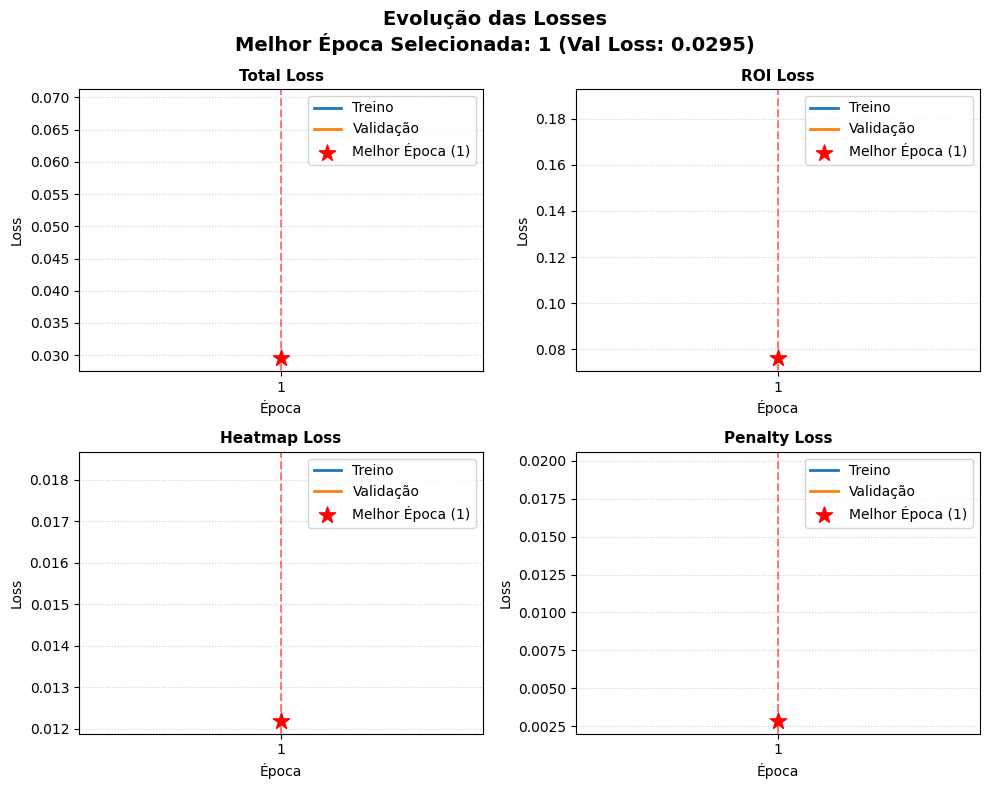

✓ Gráfico salvo: figs\UNet_ImageNet\FocalMSELoss_1ep\1782478702\fold1\loss_distributions.png


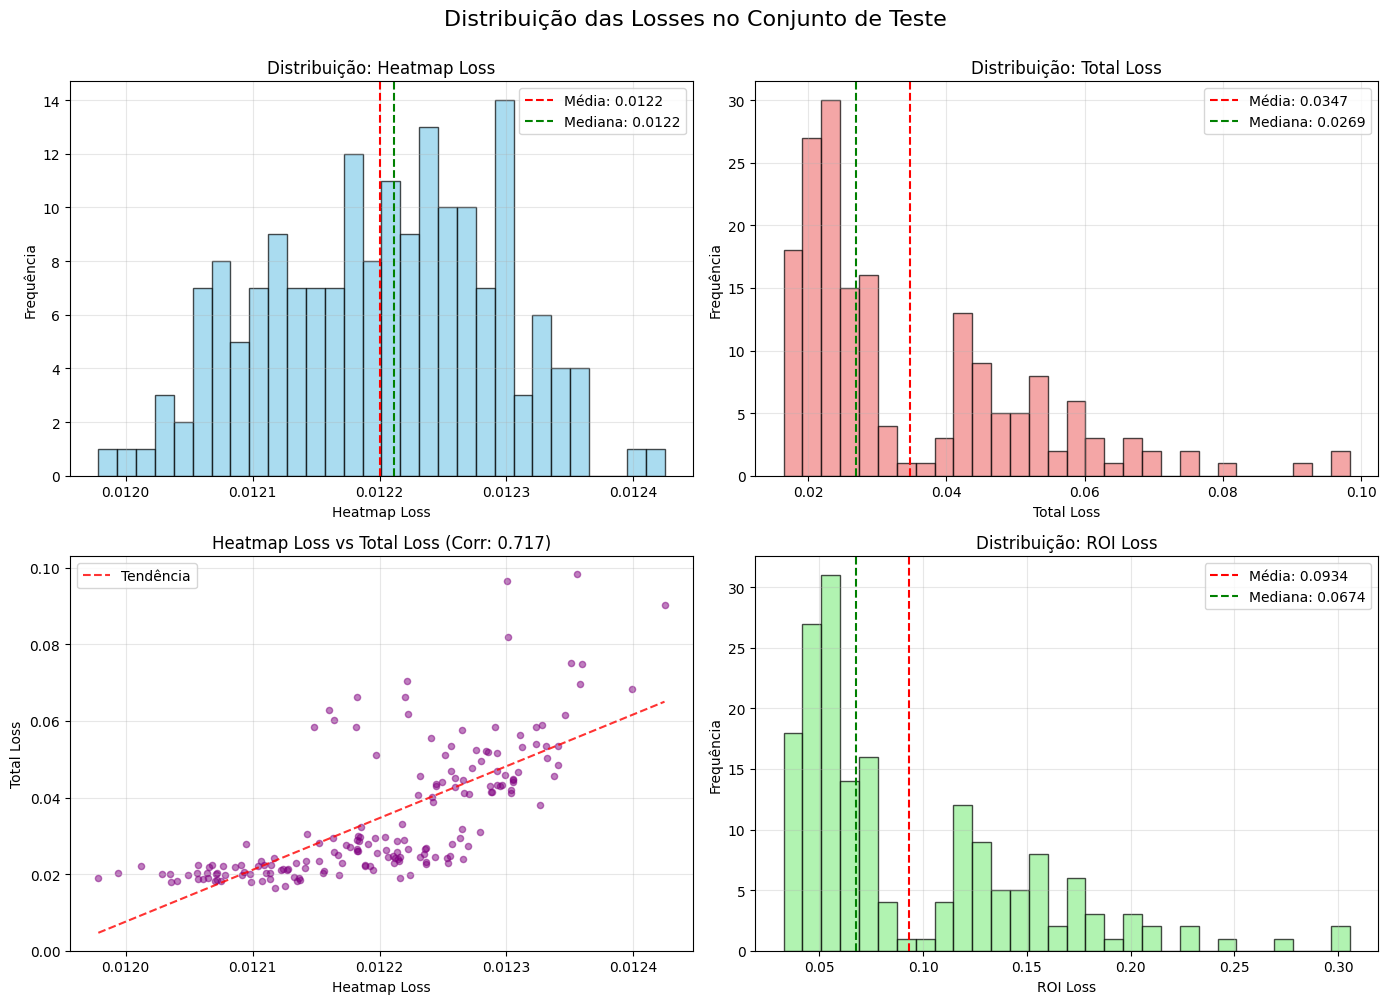

✓ Gráfico salvo: figs\UNet_ImageNet\FocalMSELoss_1ep\1782478702\fold1\keypoint_analysis.png


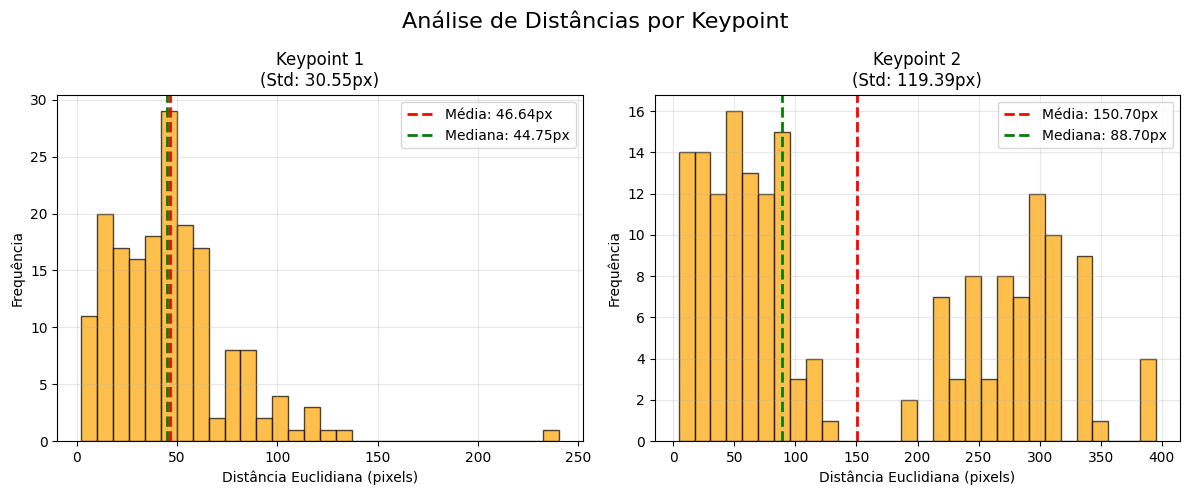


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\UNet_ImageNet\FocalMSELoss_1ep\1782478702\fold1\predictions_by_distance_keypoint1.png


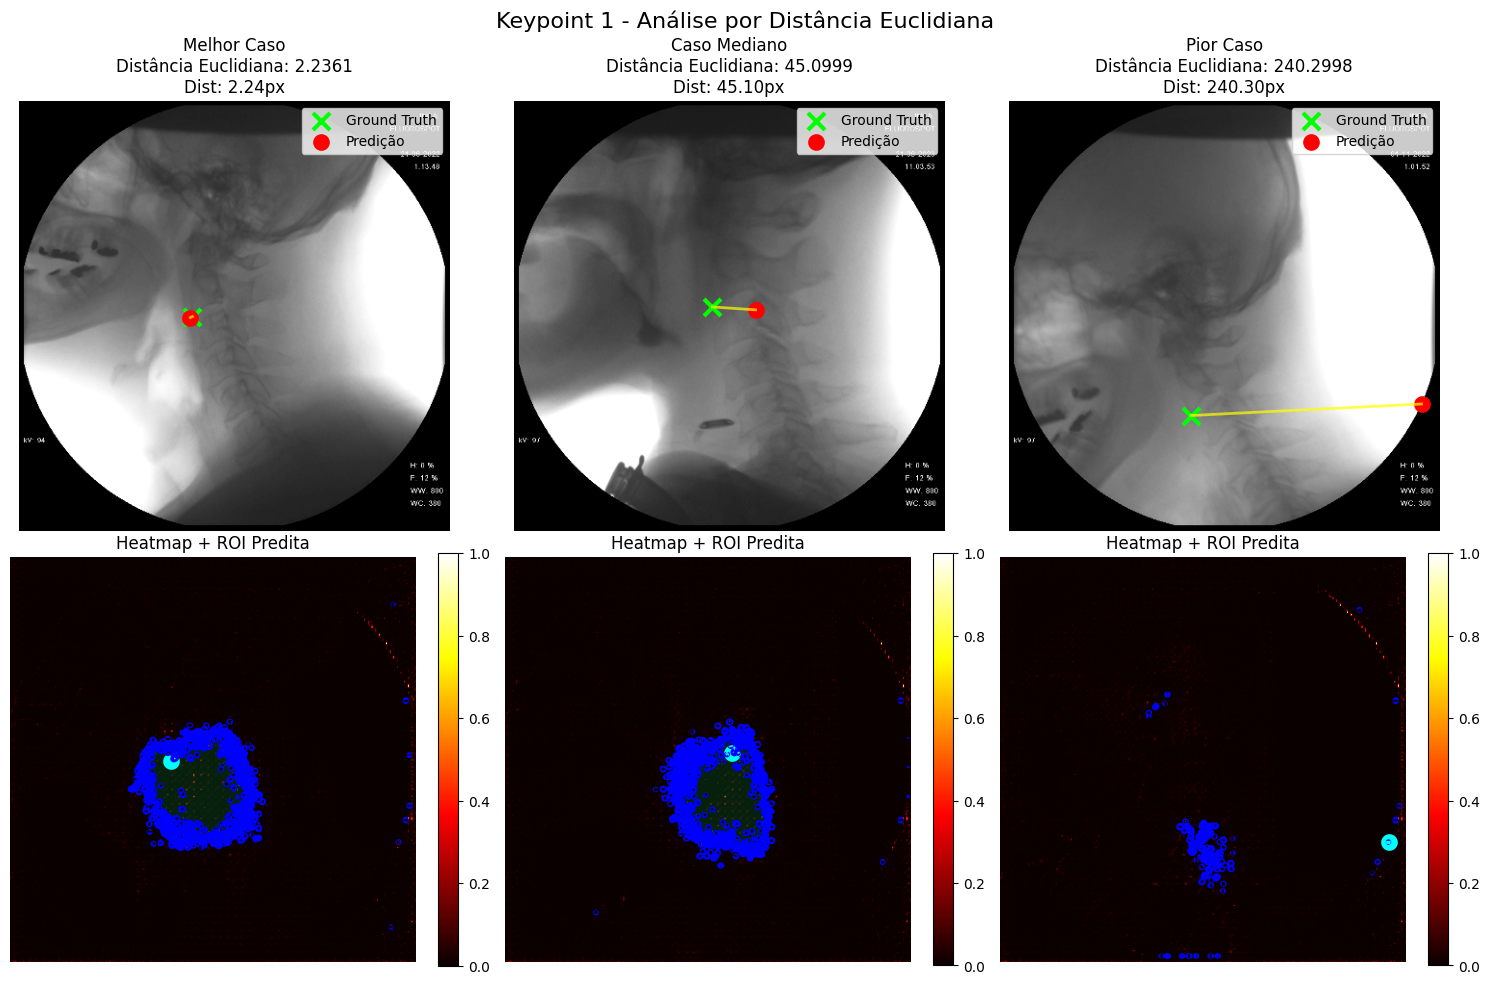


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\UNet_ImageNet\FocalMSELoss_1ep\1782478702\fold1\predictions_by_distance_keypoint2.png


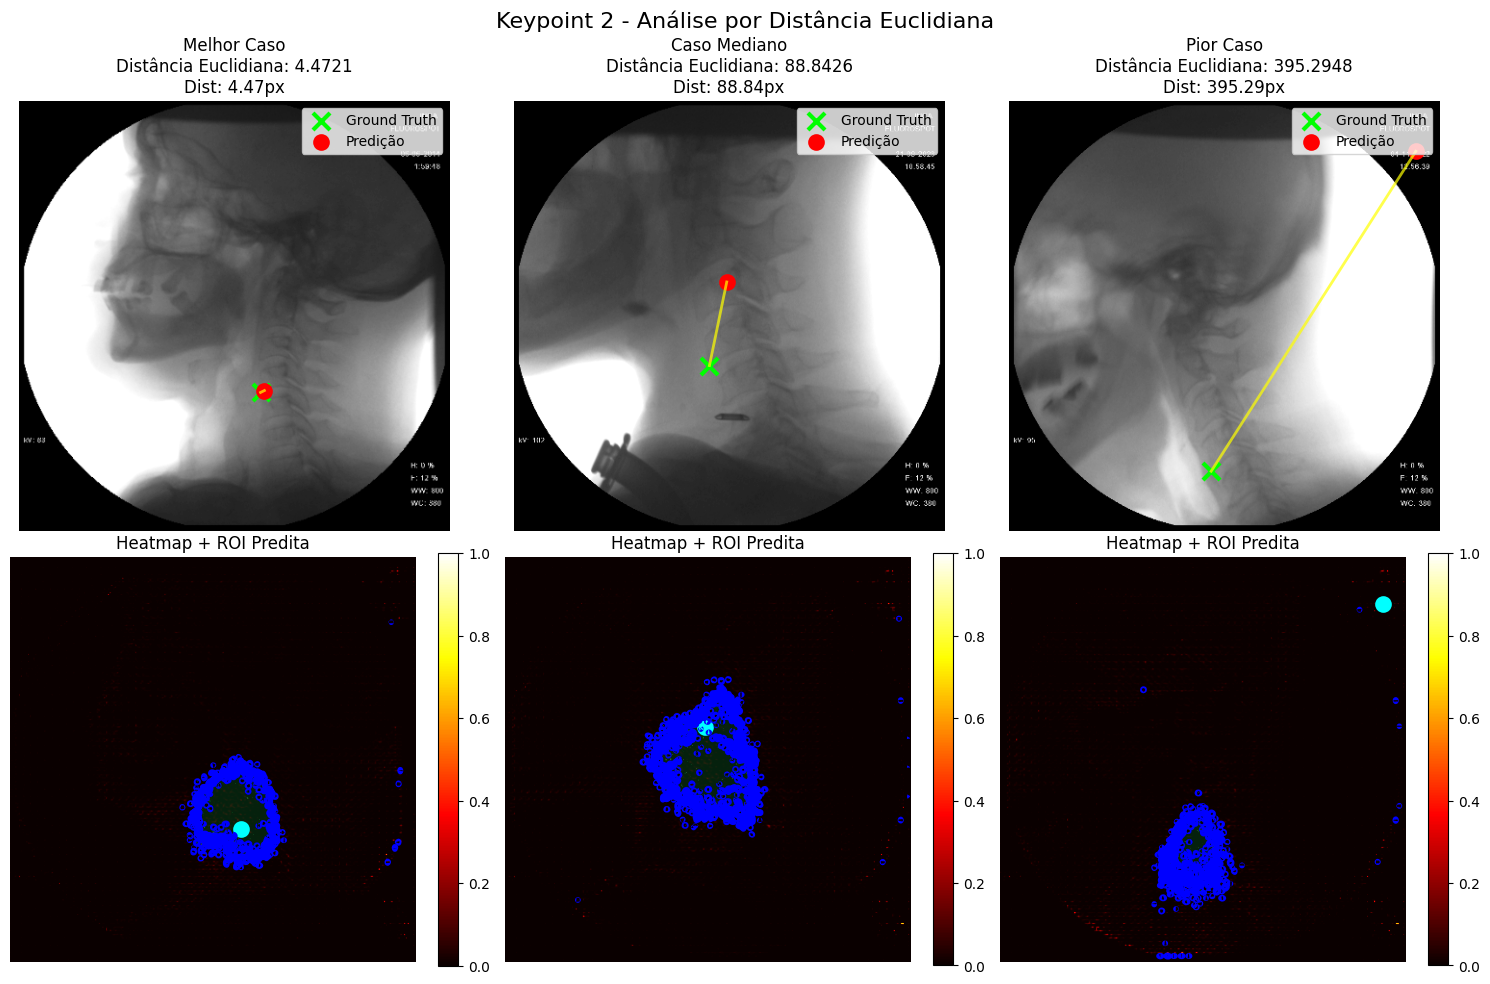


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\UNet_ImageNet\FocalMSELoss_1ep\1782478702\fold1\predictions_by_loss_keypoint1.png


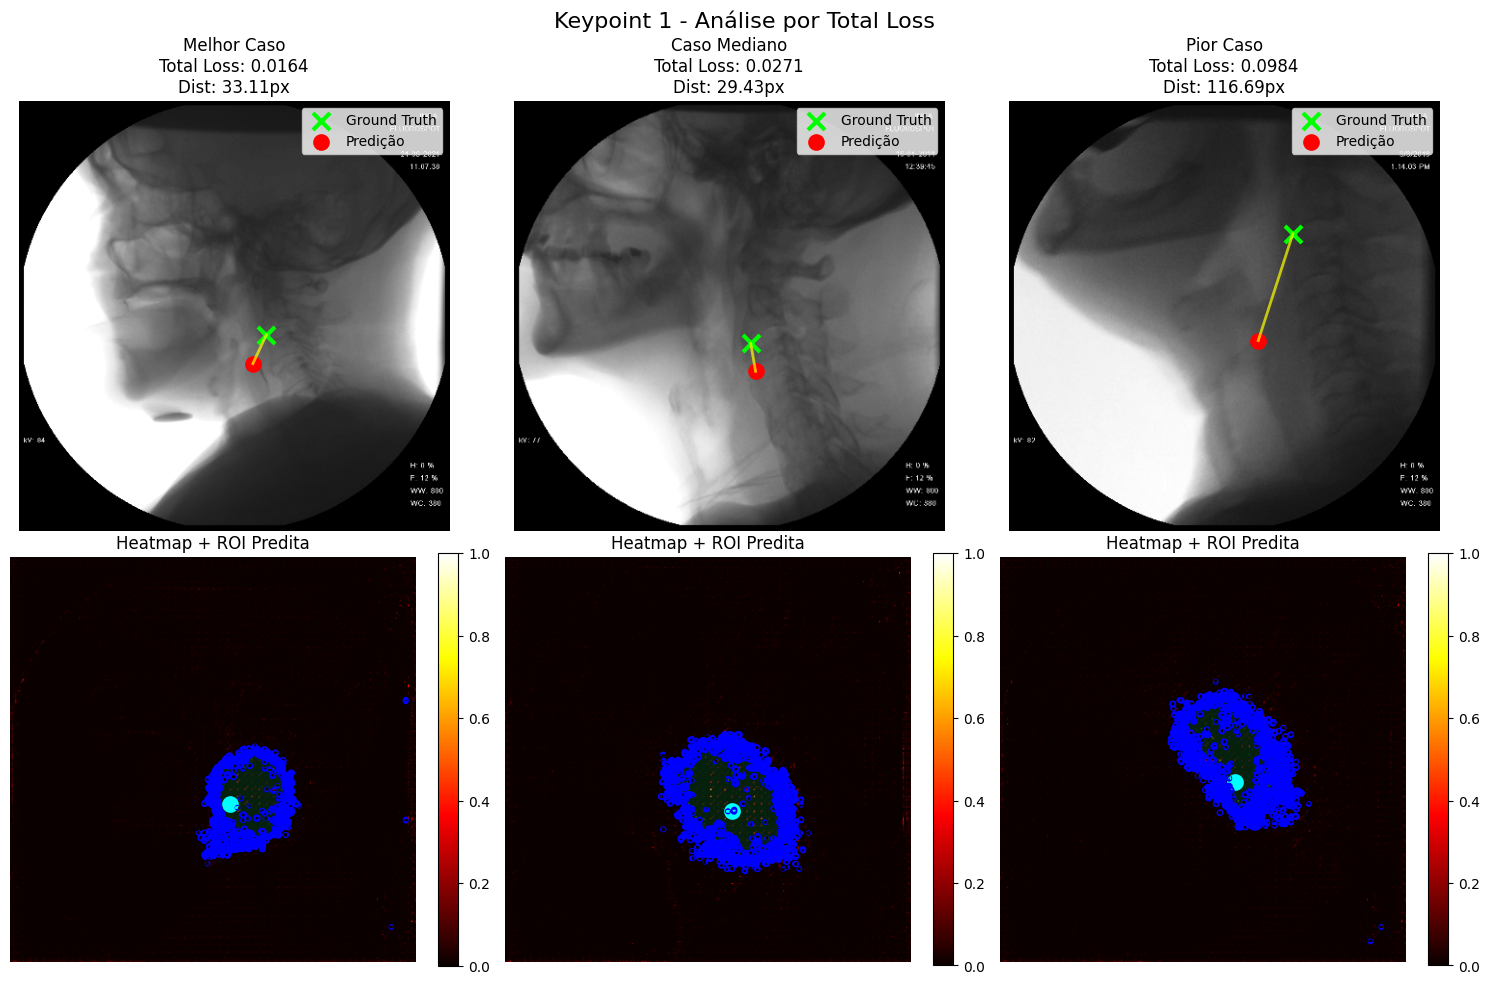


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\UNet_ImageNet\FocalMSELoss_1ep\1782478702\fold1\predictions_by_loss_keypoint2.png


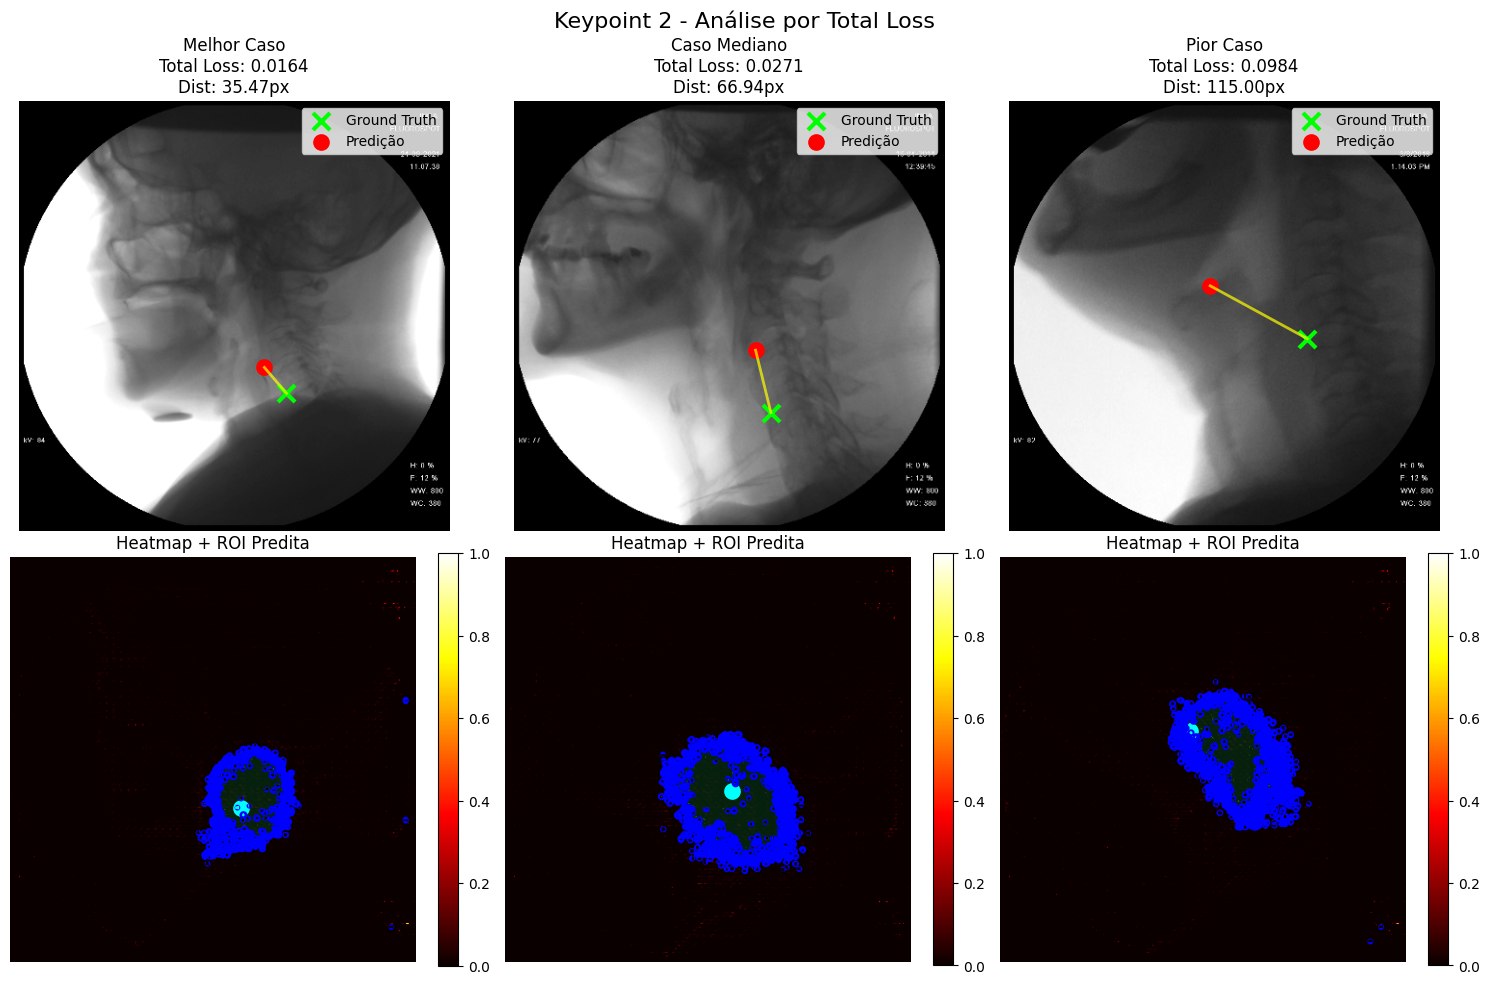

RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    0.034687
Mediana:  0.026907
Std:      0.017091
Min:      0.016438
Max:      0.098351

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.012200
Mediana:  0.012211
Std:      0.000090

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.093440
Mediana:  0.067438
Std:      0.056909

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    46.64
Mediana:  44.75
Std:      30.55
Min:      2.24
Max:      2

In [6]:
# TESTE

# MELHORAR, ao invés de chamar o config criado no arquivo,
# ler o config.pkl salvo na pasta do modelo, passar o caminho e seguir dali,
# pode ser melhor se a gente só quer ver a inferência


display_inference(config = config)